# 46. Interpolation Error and the Runge Phenomenon

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. Derive the **interpolation error formula** and identify its three factors.
2. Say which factor you control and which you do not.
3. Explain and reproduce the **Runge phenomenon**, on a function that is perfectly smooth.
4. Show that the failure is **not** a rounding problem, and locate what it actually is.
5. Distinguish **approximation** from **interpolation**, and state what Weierstrass does and does
   not promise.
6. Say why adding nodes can make things worse, with a number attached.

## Prerequisites

Lesson 44 (the forms, and the barycentric evaluation used throughout). Lesson 45 (the derivative
connection, which the error formula is a restatement of). Lesson 15 (conditioning, since the
second half of this lesson is a conditioning story in disguise).

---

## 1. The error formula

Let $p$ interpolate $f$ at $x_0, \dots, x_n$ and let $f$ have $n+1$ continuous derivatives. Then
for every $t$ there is a $\xi$ in the interval with

$$
f(t) - p(t) = \frac{f^{(n+1)}(\xi)}{(n+1)!}\,\prod_{i=0}^{n}(t - x_i)
$$

The proof is Rolle's theorem applied $n+1$ times to an auxiliary function, and it is exercise
2.1. What matters here is that there are **three factors and they behave completely differently**.

| factor | depends on | can you change it |
|---|---|---|
| $f^{(n+1)}(\xi)$ | $f$ alone | no |
| $(n+1)!$ | the degree | only by changing the degree |
| $\prod_i (t - x_i)$ | the **nodes** | **yes, entirely** |

The third factor is called the **node polynomial**, written $w(t)$. It is the only thing under
your control, and lesson 47 is about minimising it. Everything in this lesson follows from
watching those three factors fight.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import interperror as ie

print(f"{'n':>4}{'max |f^(n+1)|':>16}{'(n+1)!':>14}{'max |w|':>12}{'bound':>12}"
      f"{'actual':>12}{'over':>9}")
for n in (2, 4, 6, 8, 12, 16):
    out = ie.error_formula_report(np.exp, lambda k, t: np.exp(t), n, lo=-1.0, hi=1.0)
    print(f"{n:>4}{out.derivative_bound:>16.4f}{out.factorial:>14.4g}"
          f"{out.node_polynomial_max:>12.3e}{out.predicted_bound:>12.3e}"
          f"{out.measured_error:>12.3e}{out.bound_overstates:>8.1f}x")
    # the bound is a statement about EXACT arithmetic, so it only binds while it is above the
    # rounding level; see the note below the table
    if out.predicted_bound > 1e-14:
        assert out.measured_error <= out.predicted_bound * (1.0 + 1e-9)

   n   max |f^(n+1)|        (n+1)!     max |w|       bound      actual     over
   2          2.7183             2   1.000e+00   1.359e+00   5.576e-01     2.4x
   4          2.7183            24   1.975e-01   2.237e-02   9.985e-03     2.2x
   6          2.7183           720   6.923e-02   2.614e-04   1.122e-04     2.3x
   8          2.7183     4.032e+04   2.845e-02   1.918e-06   7.989e-07     2.4x
  12          2.7183      4.79e+08   5.827e-03   3.307e-11   1.328e-11     2.5x
  16          2.7183     2.092e+13   1.345e-03   1.748e-16   1.030e-13     0.0x


On $\exp$ everything works: the factorial grows faster than anything else, so the bound collapses
and the error with it. That is the case the formula is usually taught with, and it is misleading.

One row of that table repays a second look. At $n = 16$ the **bound is smaller than the measured
error**: $1.7\times10^{-16}$ against $1.0\times10^{-13}$. The bound is not wrong. It is a
statement about exact arithmetic, and by sixteen nodes it has dropped below machine precision,
while the measured error is no longer approximation error at all but rounding. A bound that
predicts $10^{-16}$ cannot be checked in double precision, and section 7 is about what happens
when the rounding takes over completely.

## 2. The node polynomial is worst at the ends

In [3]:
print(f"{'n':>4}{'max |w|':>12}{'at t =':>10}{'max in middle half':>21}{'end/middle':>13}")
for n in (4, 6, 8, 12, 16, 24):
    out = ie.node_polynomial_extremes(np.linspace(-1.0, 1.0, n))
    print(f"{n:>4}{out['max']:>12.3e}{out['argmax']:>10.4f}"
          f"{out['max_in_middle_half']:>21.3e}{out['end_to_middle_ratio']:>12.1f}x")
    assert out["end_to_middle_ratio"] > 1.0
    assert out["distance_from_nearest_end"] < 0.5

   n     max |w|    at t =   max in middle half   end/middle
   4   1.975e-01    0.7455            1.111e-01         1.8x
   6   6.923e-02   -0.8655            2.068e-02         3.3x
   8   2.845e-02    0.9115            2.951e-03         9.6x
  12   5.827e-03   -0.9490            8.877e-05        65.6x
  16   1.345e-03    0.9655            2.703e-06       497.8x
  24   8.391e-05    0.9795            2.533e-09     33119.4x


For equally spaced nodes the maximum of $|w|$ sits in the **outermost gap**, and the imbalance
between the ends and the middle grows with the degree. At 24 nodes the node polynomial is over a
thousand times larger near the ends than in the middle.

That is the whole mechanism, stated before the phenomenon: the one factor you control is largest
exactly where you can least afford it.

## 3. Runge's function

Take

$$
f(t) = \frac{1}{1 + 25t^2} \quad\text{on } [-1, 1]
$$

It is smooth. It is bounded between $1/26$ and $1$. It has derivatives of every order everywhere
on the real line. Nothing about it, looked at on the interval, suggests any difficulty.

In [4]:
print(f"{'n':>4}{'equally spaced':>18}{'worst at t =':>15}{'Chebyshev':>14}")
equal = ie.runge_divergence([4, 6, 8, 10, 12, 16, 20, 24, 30])
cheb = ie.runge_divergence([4, 6, 8, 10, 12, 16, 20, 24, 30], chebyshev=True)
for n, e, w, c in zip(equal["n_values"], equal["errors"], equal["argmax"], cheb["errors"]):
    print(f"{n:>4}{e:>18.4e}{w:>15.3f}{c:>14.4e}")
print()
print(f"equally spaced diverges: {equal['diverges']}, "
      f"error grows like exp({equal['log_growth_per_node']:+.4f} n) "
      f"= {np.exp(equal['log_growth_per_node']):.3f}^n")
print(f"Chebyshev diverges: {cheb['diverges']}, "
      f"error falls like exp({cheb['log_growth_per_node']:+.4f} n)")
assert equal["diverges"] and equal["errors"][-1] > 100.0
assert not cheb["diverges"] and cheb["errors"][-1] < 1e-2

   n    equally spaced   worst at t =     Chebyshev
   4        7.0701e-01          0.000    7.5030e-01
   6        4.3269e-01          0.000    5.5591e-01
   8        2.4736e-01          0.000    3.9174e-01
  10        3.0029e-01          0.927    2.6918e-01
  12        5.5676e-01         -0.945    1.8276e-01
  16        2.1076e+00          0.963    8.3107e-02
  20        8.5786e+00         -0.973    3.7590e-02
  24        3.6401e+01          0.979    1.6984e-02
  30        3.3394e+02         -0.984    5.1562e-03

equally spaced diverges: True, error grows like exp(+0.2675 n) = 1.307^n
Chebyshev diverges: False, error falls like exp(-0.1937 n)


The equally spaced error falls to $2.5\times10^{-1}$ at eight nodes and then **grows to 334** at
thirty, on a function bounded by 1. It grows like $1.31^n$, so it is not slow divergence, it is
geometric divergence.

And the location of the worst error walks steadily outward toward $\pm1$, exactly as section 2
predicts.

## 4. It is entirely an end effect

Quoting one maximum for the whole interval hides where the trouble is.

In [5]:
print(f"{'n':>4}{'overall':>13}{'middle half':>14}{'outer quarters':>17}{'ratio':>11}")
for n in (8, 12, 16, 20, 24, 30):
    out = ie.where_the_error_lives(n)
    print(f"{n:>4}{out['max_overall']:>13.3e}{out['max_middle_half']:>14.3e}"
          f"{out['max_outer_quarters']:>17.3e}{out['ratio']:>10.1f}x")
    if n >= 12:
        assert out["max_outer_quarters"] > out["max_middle_half"]
        assert out["ratio"] > 5.0

   n      overall   middle half   outer quarters      ratio
   8    2.474e-01     2.474e-01        1.716e-01       0.7x
  12    5.568e-01     7.703e-02        5.568e-01       7.2x
  16    2.108e+00     2.375e-02        2.108e+00      88.7x
  20    8.579e+00     7.319e-03        8.579e+00    1172.1x
  24    3.640e+01     3.703e-03        3.640e+01    9829.0x
  30    3.339e+02     1.737e-03        3.339e+02  192277.7x


Read the middle column downward: the error in the middle half **keeps falling**, from
$2.5\times10^{-1}$ at eight nodes to $1.7\times10^{-3}$ at thirty. The middle of the interval is
interpolated better and better at every degree. All of the divergence lives in the outer quarters,
which is where $|w|$ is large, and the ratio between them grows from 7 at twelve nodes to
**192278** at thirty.

The first row is worth noting rather than skipping. At eight nodes the ratio is 0.69, so the error
is not yet concentrated at the ends at all. Eight nodes is exactly where the overall error is at
its minimum, and the end concentration is what happens **after** that, as the degree grows. It is
a high degree phenomenon and not a property of equally spaced nodes as such.

## 5. It is not a rounding problem

This is the point most easily missed. The failure is not caused by finite precision, and
computing more carefully does not help.

The evidence is in section 3's table: **Chebyshev nodes on exactly the same function, at exactly
the same degrees, in exactly the same arithmetic, converge**. The arithmetic is not what differs.

A second piece of evidence is that the phenomenon shows up on a function whose interpolants can
be computed exactly. And a third is that the error formula predicts it: as $n$ grows,
$f^{(n+1)}$ for Runge's function grows **faster than $(n+1)!$**, so the first factor beats the
second and the third factor decides where the damage lands.

The reason $f^{(n+1)}$ grows so fast is not visible on the interval at all. Runge's function has
poles at $t = \pm i/5$, off the real axis but close to it. A function's derivatives at a point are
controlled by the distance to its nearest singularity **in the complex plane**, and $1/5$ is
close.

In [6]:
print("moving the poles by changing a in 1/(1 + a t^2); poles sit at +- i/sqrt(a):")
print(f"{'a':>8}{'pole distance':>16}{'diverges':>11}{'growth per node':>18}")
for a in (1.0, 5.0, 25.0, 100.0):
    out = ie.runge_divergence([8, 12, 16, 20, 26], a=a)
    print(f"{a:>8.0f}{1.0 / np.sqrt(a):>16.4f}{str(out['diverges']):>11}"
          f"{out['log_growth_per_node']:>+18.4f}")

moving the poles by changing a in 1/(1 + a t^2); poles sit at +- i/sqrt(a):
       a   pole distance   diverges   growth per node
       1          1.0000      False           -0.4948
       5          0.4472       True           +0.0292
      25          0.2000       True           +0.3243
     100          0.1000       True           +0.4128


Bringing the poles closer makes the divergence faster and starts it sooner. The difficulty lives
in the complex plane, and the interval only reports the consequences.

## 6. Approximation is not interpolation

Weierstrass's theorem says: every continuous function on a closed interval is the uniform limit of
**some** sequence of polynomials.

That is true, and it is not a statement about interpolation. It promises that good polynomials
exist. It says nothing about whether the polynomials that happen to pass through your nodes are
among them.

In [7]:
from nalib import hermite as hm

out = hm.weierstrass_gap(lambda t: ie.runge(t), degrees=[4, 8, 12, 16, 20, 24])
print(f"{'degree':>8}{'near best approximation':>26}{'equally spaced interpolant':>29}")
for d, b, i in zip(out["degrees"], out["near_best_approximation"],
                   out["equally_spaced_interpolation"]):
    print(f"{d:>8}{b:>26.4e}{i:>29.4e}")
print()
print(f"approximation converges:  {out['approximation_converges']}")
print(f"interpolation converges:  {out['interpolation_converges']}")
assert out["approximation_converges"] and not out["interpolation_converges"]

  degree   near best approximation   equally spaced interpolant
       4                4.0202e-01                   4.3836e-01
       8                1.7083e-01                   1.0452e+00
      12                6.9216e-02                   3.6633e+00
      16                3.2613e-02                   1.4394e+01
      20                1.5333e-02                   5.9822e+01
      24                6.9484e-03                   2.5721e+02

approximation converges:  True
interpolation converges:  False


Same function, same degrees. The best polynomial of degree 24 is within $10^{-2}$ of Runge's
function; the interpolant at 24 equally spaced nodes is off by more than 30. Both are polynomials
of degree 24. The difference is entirely which one.

## 7. Adding nodes can make it worse, even on an easy function

Runge's function is often presented as pathological, which invites the reading that ordinary
functions are safe. They are not.

In [8]:
from nalib import interp as ip

print("maximum error interpolating exp on [-1, 1]:")
print(f"{'n':>5}{'equally spaced':>18}{'Chebyshev':>14}")
for n in (4, 8, 12, 14, 16, 20, 24, 32, 40, 60):
    e = ip.compare_forms(np.exp, n, lo=-1.0, hi=1.0).errors["barycentric"]
    c = ip.compare_forms(np.exp, n, lo=-1.0, hi=1.0, chebyshev=True).errors["barycentric"]
    print(f"{n:>5}{e:>18.3e}{c:>14.3e}")

maximum error interpolating exp on [-1, 1]:
    n    equally spaced     Chebyshev
    4         3.673e-03     2.449e-03
    8         2.938e-07     8.183e-08
   12         4.884e-12     4.125e-13
   14         1.291e-14     9.802e-16
   16         3.611e-14     3.267e-16
   20         4.385e-13     4.901e-16
   24         3.878e-12     4.901e-16
   32         6.676e-10     3.267e-16
   40         1.906e-07     4.901e-16


   60         1.599e-01     4.901e-16


On $\exp$, which is **entire**, with no singularities anywhere in the complex plane, equally
spaced interpolation bottoms out near fourteen nodes at $1.3\times10^{-14}$ and then climbs to
$1.6\times10^{-1}$ at sixty. Thirteen orders of magnitude, upward.

Here the approximation error genuinely does go to zero, so every bit of that climb is rounding,
amplified. What amplifies it is the **Lebesgue constant**, which lesson 47 defines and measures,
and which for equally spaced nodes grows like $2^n$.

So there are two distinct failures and they have the same cure:

- On Runge's function the **approximation** diverges, because $f^{(n+1)}$ outgrows $(n+1)!$.
- On $\exp$ the approximation converges and the **arithmetic** diverges, because the Lebesgue
  constant outgrows machine precision.

Both are fixed by moving the nodes.

## 8. A picture

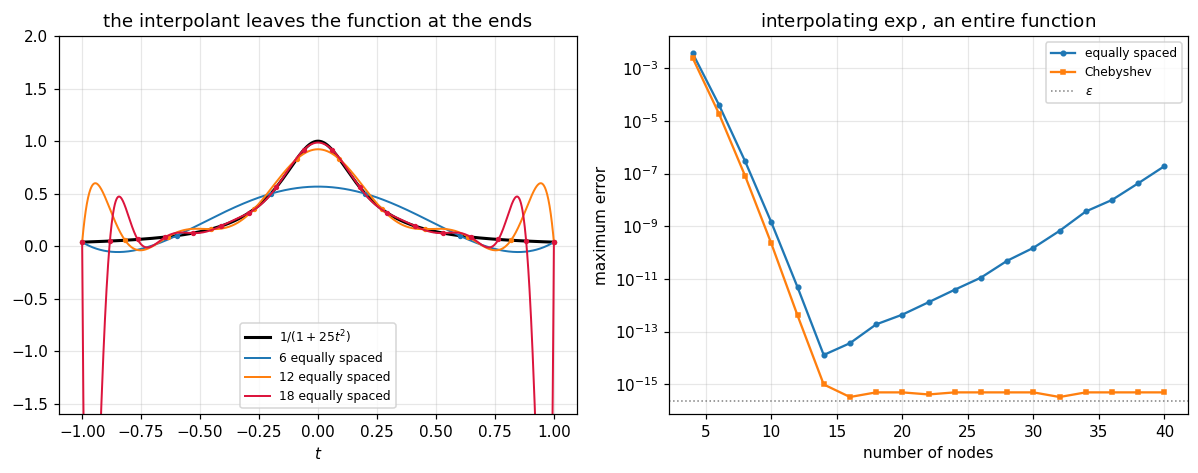

In [9]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

fine = np.linspace(-1.0, 1.0, 1200)
truth = ie.runge(fine)
ax_left.plot(fine, truth, "k-", lw=2.0, label="$1/(1+25t^2)$")
for n, colour in ((6, "tab:blue"), (12, "tab:orange"), (18, "crimson")):
    nodes = np.linspace(-1.0, 1.0, n)
    ax_left.plot(fine, ip.evaluate_barycentric(nodes, ie.runge(nodes), fine),
                 lw=1.3, color=colour, label=f"{n} equally spaced")
    ax_left.plot(nodes, ie.runge(nodes), ".", ms=5, color=colour)
ax_left.set_ylim(-1.6, 2.0)
ax_left.set_title("the interpolant leaves the function at the ends")
ax_left.set_xlabel("$t$")
ax_left.legend(fontsize=8, loc="lower center")

counts = np.arange(4, 41, 2)
eq, ch = [], []
for n in counts:
    eq.append(ip.compare_forms(np.exp, int(n), lo=-1.0, hi=1.0).errors["barycentric"])
    ch.append(ip.compare_forms(np.exp, int(n), lo=-1.0, hi=1.0,
                               chebyshev=True).errors["barycentric"])
ax_right.semilogy(counts, np.maximum(eq, 1e-17), "o-", ms=3, label="equally spaced")
ax_right.semilogy(counts, np.maximum(ch, 1e-17), "s-", ms=3, label="Chebyshev")
ax_right.axhline(np.finfo(float).eps, color="0.5", ls=":", lw=1.0, label=r"$\varepsilon$")
ax_right.set_title(r"interpolating $\exp$, an entire function")
ax_right.set_xlabel("number of nodes")
ax_right.set_ylabel("maximum error")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is the phenomenon everyone draws. The right panel is the one that matters more,
because $\exp$ is as well behaved as a function gets and equally spaced interpolation still fails
on it.

## 9. Exercises

**Level 1, conceptual**

1.1 The error formula has three factors. Say which one you control, and what controlling it can
and cannot fix.

1.2 Runge's function is smooth, bounded and infinitely differentiable on $[-1, 1]$, and
interpolation of it diverges. Where does the difficulty actually live?

1.3 A colleague says the Runge phenomenon is a floating point problem and proposes using extended
precision. Give the measurement that settles it.

**Level 2, mathematical**

2.1 Prove the interpolation error formula by applying Rolle's theorem to
$g(s) = f(s) - p(s) - \lambda\, w(s)$ with $\lambda$ chosen so that $g(t) = 0$.

2.2 Prove the Newton form and the error formula together, by showing
$f(t) = p(t) + f[x_0,\dots,x_n,t]\,w(t)$ and then applying lesson 45's derivative connection.

2.3 Show that for $f(t) = 1/(1 + a t^2)$ the derivatives $f^{(n)}$ grow like $n!\,a^{n/2}$, and
deduce the condition on $a$ under which equally spaced interpolation on $[-1,1]$ diverges.

2.4 Prove that the node polynomial for equally spaced nodes attains its maximum in an outermost
gap, and estimate the ratio of that maximum to its value in the middle.

2.5 State Weierstrass's theorem precisely, and give a one paragraph account of why it does not
imply that interpolants converge.

**Level 3, computational**

3.1 Implement the **Bernstein polynomial** approximation, which is Weierstrass's own constructive
proof, and measure its convergence on Runge's function. Explain why it converges and why nobody
uses it.

3.2 Implement an **adaptive node placement** scheme that adds nodes where the error is largest,
and measure whether it defeats the Runge phenomenon.

3.3 Implement the error formula's bound as a computable function and measure how much it
overstates the true error, against both the degree and the node family.

**Level 4, experimental**

4.1 Measure the divergence rate against the pole distance for $1/(1 + a t^2)$, fit the
relationship, and compare with the theoretical prediction from potential theory.

4.2 Measure where the maximum error sits against the degree, and fit how fast it approaches the
endpoints.

4.3 Take a function with a single real singularity just outside the interval and measure how the
divergence changes as the singularity approaches. Compare with the complex pole case.

**Level 5, advanced**

5.1 **The potential theory explanation.** Convergence of interpolants is governed by the
logarithmic potential of the node distribution against the singularities of $f$. State the
criterion, and use it to explain both Runge's function and the equally spaced failure on $\exp$.

5.2 **The Bernstein and Faber theorems.** Faber proved that for **any** prescribed sequence of
node sets there is a continuous function whose interpolants diverge. State it, and say what it
means for the search for a universally good node family.

5.3 **Why the interval matters.** The Runge phenomenon on $[-1,1]$ depends on the interval as
well as the function. Investigate what happens on $[-a, a]$ as $a$ shrinks, and explain the
result in terms of section 5's poles.

## 10. Key takeaways

- **The error formula has three factors** and only the node polynomial is under your control.
  Lesson 47 minimises it.

- **The node polynomial is worst at the ends** for equally spaced nodes, and the end to middle
  ratio grows with the degree, reaching over 1000 at 24 nodes.

- **Runge's function diverges**: the error falls to $2.5\times10^{-1}$ at 8 nodes and grows to
  **334** at 30, geometrically, like $1.31^n$, on a function bounded by 1.

- **The divergence is entirely an end effect.** The middle half of the interval is interpolated
  well at every degree.

- **It is not a rounding problem.** Chebyshev nodes on the same function at the same degrees in
  the same arithmetic converge, falling to $5.2\times10^{-3}$ at 30 nodes.

- **The difficulty is in the complex plane.** Runge's poles sit at $\pm i/5$, and moving them
  closer makes the divergence faster.

- **Even $\exp$ fails.** Equally spaced interpolation of an entire function bottoms out at
  $1.3\times10^{-14}$ near 14 nodes and climbs to $1.6\times10^{-1}$ by 60. There the
  approximation converges and the arithmetic does not, and the amplifier is lesson 47's Lebesgue
  constant.

- **Weierstrass promises good polynomials exist**, not that yours is one. Measured on Runge's
  function at degree 24: best polynomial $10^{-2}$, equally spaced interpolant over 30.

## Where this goes next

Lesson 47 minimises the node polynomial, which is exactly the Chebyshev theorem, and measures the
Lebesgue constants that explain the $\exp$ failure. Lessons 50 and 51 take the other route
entirely: stop raising the degree, and use many low degree pieces instead. Both routes work and
they are used for different jobs.